# NumPy

**What you'll learn:** how to create, inspect, slice, reshape, combine and calculate with arrays, then generate random data and use _ufuncs_ (fast math functions).

**Roadmap**

1. creating arrays, indexing, slicing
2. Data types, copy vs view, shape & reshape
3. Iterating, joining, splitting, searching, sorting, filtering
4. Random numbers & distributions
5. ufuncs (universal functions)


## 1. Introduction

**NumPy** (_Numerical Python_) is a library for working with **arrays**: fast, memory-efficient containers of numbers.

**Why not just use Python lists?**

- NumPy arrays are much **faster**.
- You can do math on the **whole array at once** without writing loops.

Install it once with `pip install numpy`, then import it. By convention we call it `np`.


In [1]:
import numpy as np

print("NumPy version:", np.__version__)

# List vs NumPy array: same data, different power
my_list = [1, 2, 3, 4]
arr = np.array([1, 2, 3, 4])

print("list * 2   ->", my_list * 2)   # repeats the list
print("array * 2  ->", arr * 2)       # multiplies every element

NumPy version: 2.2.4
list * 2   -> [1, 2, 3, 4, 1, 2, 3, 4]
array * 2  -> [2 4 6 8]


## 2. Creating Arrays

The main tool is `np.array()`. Arrays can have different **dimensions**:

| Dimension | Name   | Example            |
| --------- | ------ | ------------------ |
| 0-D       | scalar | `5`                |
| 1-D       | vector | `[1, 2, 3]`        |
| 2-D       | matrix | `[[1, 2], [3, 4]]` |
| 3-D       | tensor | a list of matrices |

`ndim` tells you the number of dimensions. NumPy also has shortcuts to build arrays quickly: `zeros`, `ones`, `arange`.


In [3]:
a0 = np.array(42)
a1 = np.array([1, 2, 3])
a2 = np.array([[1, 2, 3], [4, 5, 6]])
a3 = np.array([[[1, 2], [3, 4]], [[5, 6], [7, 8]]])

for a in (a0, a1, a2, a3):
    print(a.ndim, "D ->", a.tolist())

print("-" * 30)
print("zeros   :", np.zeros(4))
print("ones    :", np.ones((2, 5)))
print("arange  :", np.arange(0, 10, 2))      # start, stop (excluded), step

0 D -> 42
1 D -> [1, 2, 3]
2 D -> [[1, 2, 3], [4, 5, 6]]
3 D -> [[[1, 2], [3, 4]], [[5, 6], [7, 8]]]
------------------------------
zeros   : [0. 0. 0. 0.]
ones    : [[1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]]
arange  : [0 2 4 6 8]


## 3. Array Indexing

Indexing means getting **one element**. Remember: counting starts at **0**, and negative indexes count from the end (`-1` = last).

For 2-D arrays use `array[row, column]`.


In [3]:
arr = np.array([10, 20, 30, 40, 50])
print("first :", arr[0])
print("last  :", arr[-1])

m = np.array([[1, 2, 3],
              [4, 5, 6]])
print("row 1, col 2 ->", m[1, 2])   # 6

first : 10
last  : 50
row 1, col 2 -> 6


## 4. Array Slicing

Slicing means getting **a part** of the array using `[start:stop:step]`.

- `start` is included, `stop` is **not** included.
- Leave a part empty to use the default (beginning / end / step 1).


In [4]:
arr = np.array([0, 1, 2, 3, 4, 5, 6])

print(arr[1:4])    # [1 2 3]
print(arr[:3])     # from the beginning
print(arr[4:])     # to the end
print(arr[::-1])   # reversed!

m = np.array([[1, 2, 3, 4],
              [5, 6, 7, 8]])
print(m[0:2, 1:3])   # rows 0-1, columns 1-2

[1 2 3]
[0 1 2]
[4 5 6]
[6 5 4 3 2 1 0]
[[2 3]
 [6 7]]


## 5. Data Types

Unlike lists, a NumPy array holds **one data type** for all its elements (this is what makes it fast).

Common types: `int64`, `float64`, `bool`, `str` (`<U..`). Check it with `.dtype`, and convert with `.astype()`.


In [ ]:
ints = np.array([1, 2, 3])
floats = np.array([1.5, 2.5, 3.5])
print(ints.dtype, floats.dtype)

# Mixed values -> NumPy picks one type that fits everything
mixed = np.array([1, 2.5, 3])
print(mixed, mixed.dtype)

# Converting types
converted = floats.astype(int)       # decimals are cut off
print(converted)

print(np.array([0, 1, 5]).astype(bool))   # 0 -> False, others -> True

int64 float64
[1.  2.5 3. ] float64
[1 2 3]
[False  True  True]


## 6. Copy vs View

This is a classic beginner trap!

- `.copy()` creates a **new, independent** array. Changing it does **not** affect the original.
- `.view()` (and slicing) is just **another window on the same data**. Changing it **does** change the original.

Use `arr.base` to check: it's `None` for a copy and points to the original array for a view.


In [6]:
original = np.array([1, 2, 3, 4, 5])

c = original.copy()
v = original.view()

c[0] = 99     # change the copy
print("after changing copy:", original)   # unchanged

v[0] = 77     # change the view
print("after changing view:", original)   # changed!

print("copy.base:", c.base)
print("view.base:", v.base is original)

after changing copy: [1 2 3 4 5]
after changing view: [77  2  3  4  5]
copy.base: None
view.base: True


## 7. Array Shape & Reshape

- `.shape` returns a tuple with the size of each dimension: `(rows, columns)`.
- `.reshape()` changes the shape **without changing the data**. The total number of elements must stay the same (12 elements can become 3×4, 2×6, 4×3 ...).
- Use `-1` to let NumPy calculate one dimension for you.
- `.flatten()` turns any array back into 1-D.


In [7]:
arr = np.arange(1, 13)          # 1..12
print("shape:", arr.shape)

m = arr.reshape(3, 4)
print(m)
print("new shape:", m.shape)

print(arr.reshape(2, -1).shape)  # NumPy figures out: (2, 6)
print(m.flatten())

shape: (12,)
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
new shape: (3, 4)
(2, 6)
[ 1  2  3  4  5  6  7  8  9 10 11 12]


## 8. Array Iterating

You can loop over an array with a normal `for` loop. For 2-D arrays you get one **row** per loop.

For arrays with any number of dimensions, `np.nditer()` visits **every single element**.


In [4]:
m = np.array([[1, 2, 3],
              [4, 5, 6]])

print("Row by row:")
for row in m:
    print(row)

print("Element by element:")
for x in np.nditer(m):
    print(x, end=" ")

print()

for i in m:
    for j in i:
        print(j, end='')

Row by row:
[1 2 3]
[4 5 6]
Element by element:
1 2 3 4 5 6 
123456

## 9. Array Join & Split

**Join** (combine arrays)

- `np.concatenate((a, b), axis=...)`: join along an existing axis.
- `np.vstack` (vertical / stack rows) and `np.hstack` (horizontal / stack columns) **Must be the same dimension**.

**Split** (break an array into parts)

- `np.array_split(arr, n)`: split into `n` parts (returns a list of arrays).


In [9]:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

print(np.concatenate((a, b)))
print(np.vstack((a, b)))
print(np.hstack((a, b)))

print("-" * 30)
arr = np.arange(1, 7)
parts = np.array_split(arr, 3)
print(parts)
print("first part:", parts[0])

[1 2 3 4 5 6]
[[1 2 3]
 [4 5 6]]
[[1 2 5 6]
 [3 4 7 8]]
------------------------------
[array([1, 2]), array([3, 4]), array([5, 6])]
first part: [1 2]


## 10. Array Search, Sort & Filter

**Search**

- `np.where(condition)` returns the **indexes** where the condition is true.
- `np.searchsorted(arr, value)` finds where a value should be inserted in a **sorted** array.

**Sort**

- `np.sort(arr)` returns a sorted **copy** (original unchanged).

**Filter**

- Use a **boolean mask** (a list of `True`/`False`) to keep only the elements you want.


In [10]:
arr = np.array([41, 12, 35, 8, 27, 12])

# Search
print("indexes of 12:", np.where(arr == 12))
print("even numbers at:", np.where(arr % 2 == 0))

sorted_arr = np.sort(arr)
print("sorted:", sorted_arr)
print("insert 30 at index:", np.searchsorted(sorted_arr, 30))

# Filter with a boolean mask
mask = arr > 20
print("mask  :", mask)
print("filter:", arr[mask])          # same as arr[arr > 20]

indexes of 12: (array([1, 5]),)
even numbers at: (array([1, 3, 5]),)
sorted: [ 8 12 12 27 35 41]
insert 30 at index: 4
mask  : [ True False  True False  True False]
filter: [41 35 27]


# Random Module

## 11. Random Numbers

NumPy's `np.random` generates random data, useful for simulations, testing and machine learning.

The modern way is to create a **generator** with `np.random.default_rng()`.
Pass a **seed** to get the _same_ "random" numbers every time (great for reproducible results).

Main methods: `random()` (floats between 0 and 1), `integers()`, `choice()`, `shuffle()` / `permutation()`.


In [15]:
rng = np.random.default_rng(seed=42)

print("floats  :", rng.random(3))
print("integers:", rng.integers(1, 7, size=5))       # like rolling a die (7 is excluded)
print("choice  :", rng.choice(["red", "green", "blue"]))

# Random permutation: shuffle the order of elements
cards = np.arange(1, 6)
print("permutation:", rng.permutation(cards))        # returns a shuffled copy

floats  : [0.77395605 0.43887844 0.85859792]
integers: [1 5 2 1 4]
choice  : blue
permutation: [3 5 1 4 2]


## 12. Data Distributions

A **distribution** describes _how likely each value is_. Instead of every value being equally likely, many real-life things follow a pattern. The most important ones:

| Distribution          | Meaning / Example                                                 |
| --------------------- | ----------------------------------------------------------------- |
| **Uniform**           | All values equally likely (rolling a fair die)                    |
| **Normal** (Gaussian) | Bell curve, most values near the mean (people's heights)          |
| **Binomial**          | Number of successes in `n` yes/no trials (heads in 10 coin flips) |
| **Poisson**           | Number of events in a fixed time (customers per hour)             |

We'll draw them with **matplotlib** histograms (a bar chart showing how often values appear).


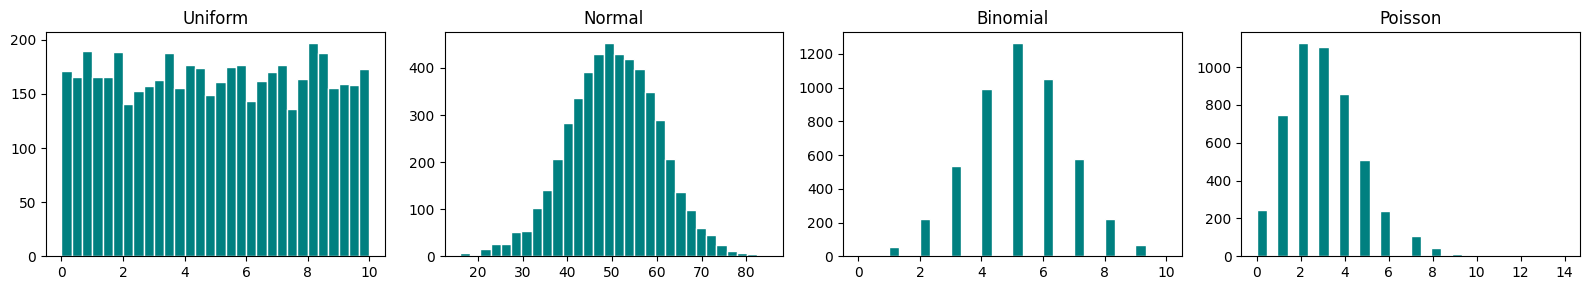

In [12]:
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
size = 5000

samples = {
    "Uniform":  rng.uniform(0, 10, size),
    "Normal":   rng.normal(loc=50, scale=10, size=size),   # mean=50, std=10
    "Binomial": rng.binomial(n=10, p=0.5, size=size),
    "Poisson":  rng.poisson(lam=3, size=size),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for ax, (name, data) in zip(axes, samples.items()):
    ax.hist(data, bins=30, color="teal", edgecolor="white")
    ax.set_title(name)
plt.tight_layout()
plt.show()

**Other distributions you'll meet later** (same idea, different shapes): _Logistic, Multinomial, Exponential, Chi-Square, Rayleigh, Pareto, Zipf_. They all work like the code above: `rng.<name>(parameters, size)`. As a beginner, focusing on **Uniform** and **Normal** is enough.


## 13. Arithmetic & Rounding

**Arithmetic** ufuncs: `add`, `subtract`, `multiply`, `divide`, `power`, `mod` (same as `+ - * / ** %`).

**Rounding** ufuncs:

- `np.round(arr, decimals)`: round to the given decimals
- `np.floor`: always round **down**
- `np.ceil`: always round **up**
- `np.trunc`: just cut off the decimals


In [15]:
a = np.array([10, 20, 30])
b = np.array([3, 4, 5])
print("add     :", np.add(a, b))
print("multiply:", np.multiply(a, b))
print("power   :", np.power(b, 2))
print("mod     :", np.mod(a, b))

print("-" * 30)
x = np.array([-3.678, 2.5, 4.123])
print("round(1):", np.round(x, 1))
print("floor   :", np.floor(x))
print("ceil    :", np.ceil(x))
print("trunc   :", np.trunc(x))

add     : [13 24 35]
multiply: [ 30  80 150]
power   : [ 9 16 25]
mod     : [1 0 0]
------------------------------
round(1): [-3.7  2.5  4.1]
floor   : [-4.  2.  4.]
ceil    : [-3.  3.  5.]
trunc   : [-3.  2.  4.]


## 14. Logs, Trigonometric & Hyperbolic Functions

- **Logarithms**: `np.log` (natural, base _e_), `np.log2`, `np.log10`.
- **Trigonometric**: `np.sin`, `np.cos`, `np.tan` work with **radians**. Convert degrees with `np.deg2rad`.
- **Hyperbolic**: `np.sinh`, `np.cosh`, `np.tanh` follow the same pattern (you'll mostly see `tanh` in machine learning).


In [16]:
x = np.array([1, 10, 100])
print("log10:", np.log10(x))
print("log2 :", np.log2(np.array([2, 8, 16])))

angles = np.deg2rad(np.array([0, 30, 90]))   # degrees -> radians
print("sin  :", np.round(np.sin(angles), 2))
print("cos  :", np.round(np.cos(angles), 2))
print("tanh :", np.round(np.tanh(np.array([-2, 0, 2])), 2))

log10: [0. 1. 2.]
log2 : [1. 3. 4.]
sin  : [0.  0.5 1. ]
cos  : [1.   0.87 0.  ]
tanh : [-0.96  0.    0.96]


## 15. Summations, Products & Differences

These work on **many** elements and reduce them to fewer values:

- `np.sum`: total, `np.cumsum`: running total
- `np.prod`: multiply everything, `np.cumprod`: running product
- `np.diff`: difference between each element and the previous one

For 2-D arrays, use `axis=0` (down the columns) or `axis=1` (across the rows).


In [17]:
arr = np.array([1, 2, 3, 4])
print("sum    :", np.sum(arr))
print("cumsum :", np.cumsum(arr))
print("prod   :", np.prod(arr))
print("diff   :", np.diff(np.array([10, 15, 25, 40])))

m = np.array([[1, 2, 3],
              [4, 5, 6]])
print("sum by column (axis=0):", m.sum(axis=0))
print("sum by row    (axis=1):", m.sum(axis=1))

sum    : 10
cumsum : [ 1  3  6 10]
prod   : 24
diff   : [ 5 10 15]
sum by column (axis=0): [5 7 9]
sum by row    (axis=1): [ 6 15]


## 16. Finding LCM & GCD

- **LCM** (Lowest Common Multiple): `np.lcm(a, b)`; use `np.lcm.reduce(arr)` for a whole array.
- **GCD** (Greatest Common Divisor): `np.gcd(a, b)`; use `np.gcd.reduce(arr)` for a whole array.


In [18]:
print("lcm(4, 6)  :", np.lcm(4, 6))
print("gcd(12, 18):", np.gcd(12, 18))

arr = np.array([3, 6, 9])
print("lcm of all :", np.lcm.reduce(arr))
print("gcd of all :", np.gcd.reduce(arr))

lcm(4, 6)  : 12
gcd(12, 18): 6
lcm of all : 18
gcd of all : 3


## 17. Set Operations

A **set** has only **unique** values. NumPy can treat arrays like sets:

- `np.unique(arr)`: remove duplicates (and sort)
- `np.union1d(a, b)`: all values from both
- `np.intersect1d(a, b)`: values found in **both**
- `np.setdiff1d(a, b)`: values in `a` that are **not** in `b`


In [19]:
a = np.array([1, 2, 2, 3, 4])
b = np.array([3, 4, 5, 6])

print("unique   :", np.unique(a))
print("union    :", np.union1d(a, b))
print("intersect:", np.intersect1d(a, b))
print("a - b    :", np.setdiff1d(a, b))

unique   : [1 2 3 4]
union    : [1 2 3 4 5 6]
intersect: [3 4]
a - b    : [1 2]


## Summary

| Topic                 | Remember                                                      |
| --------------------- | ------------------------------------------------------------- |
| Create                | `np.array`, `zeros`, `ones`, `arange`, `linspace`             |
| Access                | `arr[i]`, `arr[start:stop:step]`, `arr[row, col]`             |
| Shape                 | `.shape`, `.reshape()`, `.flatten()`                          |
| Copy vs View          | `.copy()` is independent, `.view()` / slices share data       |
| Combine / Split       | `concatenate`, `vstack`, `hstack`, `array_split`              |
| Find / Order / Filter | `where`, `sort`, boolean mask                                 |
| Random                | `default_rng(seed)`, `random`, `integers`, `choice`, `normal` |

## Practice Exercises

1. Create an array of numbers from 1 to 20, reshape it to `(4, 5)`, and print the sum of each row.
2. From the array `[5, 12, 7, 20, 3, 18]`, keep only the numbers greater than 6 and sort them.
3. Generate 1000 numbers from a normal distribution (mean 0, std 1) and print their mean using `np.mean`.
4. Given `a = [1, 2, 3, 4]` and `b = [3, 4, 5]`, find the numbers they have in common.
